### Wstęp do Uczenia Maszynowego - praca domowa 1
##### Stanisław Frelik
##### 22.10.2023

### Przygotowanie zbiorków danych
---------

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [28]:
X = pd.read_csv("X.csv")
y = pd.read_csv("y.csv")

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=320553)

#### Eksperyment
--------

O kryterium podziału

In [103]:
Tree = tree.DecisionTreeClassifier(criterion="entropy", random_state=320553)
scores_all_entropy = []
for i in range(0, 200):
    scores = cross_val_score(Tree, X_train, y_train, cv = 5, scoring = 'roc_auc')
    scores_all_entropy.append(scores)

Tree = tree.DecisionTreeClassifier(criterion="gini")
scores_all_gini = []
for i in range(0, 200):
    scores = cross_val_score(Tree, X_train, y_train, cv = 5, scoring = 'roc_auc')
    scores_all_gini.append(scores)

In [110]:
df_entropy = pd.DataFrame(scores_all_entropy)
df_gini = pd.DataFrame(scores_all_gini)

In [111]:
print("Entropy: %0.4f accuracy with a standard deviation of %0.6f" % (df_entropy.aggregate(["mean", "std"], axis=1)["mean"].mean(), df_entropy.aggregate(["mean", "std"], axis=1)["std"].std()))
print("Gini: %0.4f accuracy with a standard deviation of %0.6f" % (df_gini.aggregate(["mean", "std"], axis=1)["mean"].mean(), df_gini.aggregate(["mean", "std"], axis=1)["std"].std()))

Entropy: 0.8243 accuracy with a standard deviation of 0.000000
Gini: 0.8182 accuracy with a standard deviation of 0.001529


<AxesSubplot:>

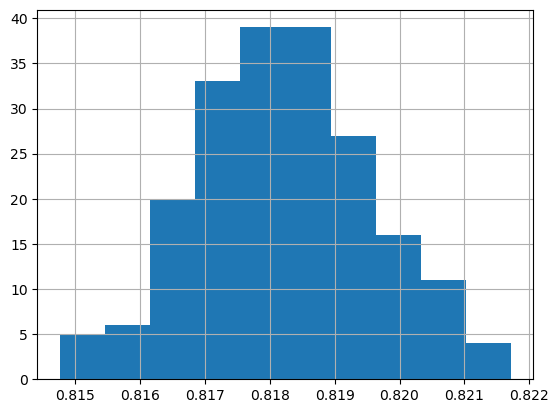

In [113]:
df_entropy.aggregate(["mean", "std"], axis=1)["mean"].hist()
df_gini.aggregate(["mean", "std"], axis=1)["mean"].hist()

<AxesSubplot:>

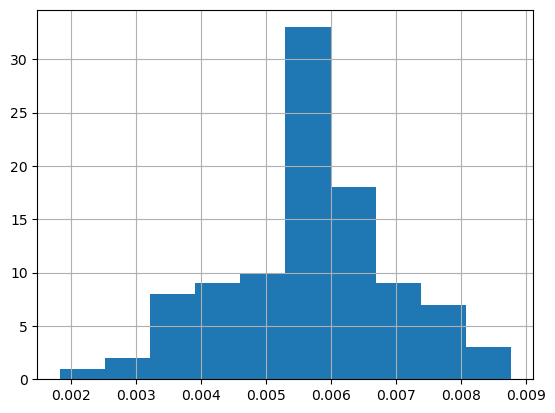

In [99]:
df_entropy.aggregate(["mean", "std"], axis=1)["std"].hist()

<AxesSubplot:>

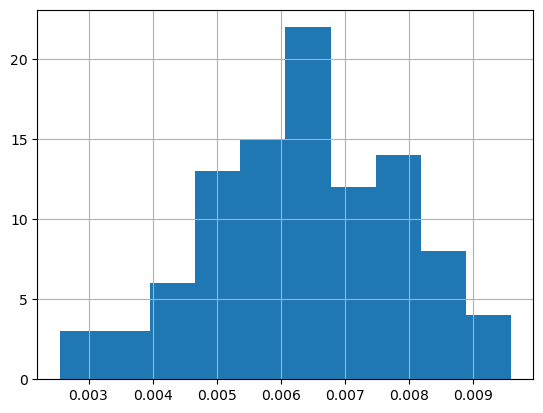

In [40]:
df_gini.aggregate(["mean", "std"], axis=1)["std"].hist()

O głębokości drzew

In [128]:
scores_all_depth = []
for j in range(2, 20, 2):
    Tree = tree.DecisionTreeClassifier(criterion="entropy", max_depth=j, random_state=320553)
    scores_all = []
    for i in range(0, 100):
        scores = cross_val_score(Tree, X_train, y_train, cv = 5, scoring = 'roc_auc')
        scores_all.append(scores)
    scores_all_depth.append(pd.DataFrame(scores_all))

In [129]:
for i in range(0, len(scores_all_depth)):
    scores_all_depth[i] = scores_all_depth[i].aggregate(["mean", "std"], axis=1)
    print("Max depth = %0.1f: %0.4f accuracy with a standard deviation of %0.6f" % (2 + 2 * i, scores_all_depth[i]["mean"].mean(), scores_all_depth[i]["std"].std()))

Max depth = 2.0: 0.6879 accuracy with a standard deviation of 0.000000
Max depth = 4.0: 0.7867 accuracy with a standard deviation of 0.000000
Max depth = 6.0: 0.8522 accuracy with a standard deviation of 0.000000
Max depth = 8.0: 0.8726 accuracy with a standard deviation of 0.000000
Max depth = 10.0: 0.8640 accuracy with a standard deviation of 0.000000
Max depth = 12.0: 0.8492 accuracy with a standard deviation of 0.000000
Max depth = 14.0: 0.8350 accuracy with a standard deviation of 0.000000
Max depth = 16.0: 0.8282 accuracy with a standard deviation of 0.000000
Max depth = 18.0: 0.8254 accuracy with a standard deviation of 0.000000


O minimalnej liczby obserwacji w liściu

In [130]:
scores_all_min_smp_leaf = []
for j in range(24, 49, 4):
    Tree = tree.DecisionTreeClassifier(criterion="entropy", max_depth=8, min_samples_leaf=j, random_state=320553)
    scores_all = []
    for i in range(0, 100):
        scores = cross_val_score(Tree, X_train, y_train, cv = 5, scoring = 'roc_auc')
        scores_all.append(scores)
    scores_all_min_smp_leaf.append(pd.DataFrame(scores_all))

In [115]:
for i in range(0, len(scores_all_min_smp_leaf)):
    scores_all_min_smp_leaf[i] = scores_all_min_smp_leaf[i].aggregate(["mean", "std"], axis=1)
    print("Min sample leaf = %0.1f: %0.4f accuracy with a standard deviation of %0.6f" % (4 + 4 * i, scores_all_min_smp_leaf[i]["mean"].mean(), scores_all_min_smp_leaf[i]["std"].std()))

Min sample leaf = 4.0: 0.8690 accuracy with a standard deviation of 0.000000
Min sample leaf = 8.0: 0.8713 accuracy with a standard deviation of 0.000000
Min sample leaf = 12.0: 0.8738 accuracy with a standard deviation of 0.000000
Min sample leaf = 16.0: 0.8775 accuracy with a standard deviation of 0.000000
Min sample leaf = 20.0: 0.8769 accuracy with a standard deviation of 0.000000
Min sample leaf = 24.0: 0.8767 accuracy with a standard deviation of 0.000000
Min sample leaf = 28.0: 0.8770 accuracy with a standard deviation of 0.000000
Min sample leaf = 32.0: 0.8770 accuracy with a standard deviation of 0.000000
Min sample leaf = 36.0: 0.8781 accuracy with a standard deviation of 0.000000
Min sample leaf = 40.0: 0.8782 accuracy with a standard deviation of 0.000000
Min sample leaf = 44.0: 0.8777 accuracy with a standard deviation of 0.000000


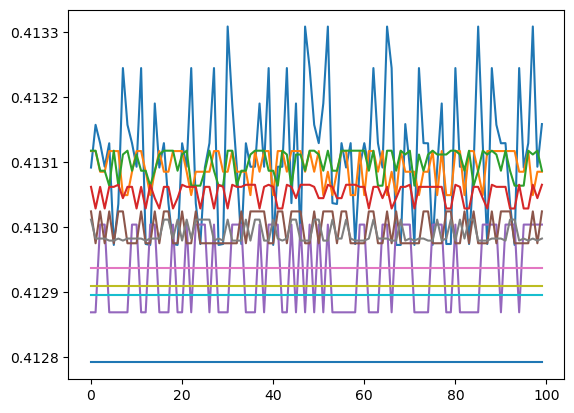

In [14]:
for i in range(0, len(scores_all_min_smp_leaf)):
    plt.plot(scores_all_min_smp_leaf[i]["mean"])

O min_samples_split

In [137]:
scores_all_min_smp_split = []
for j in range(18, 26, 1):
    Tree = tree.DecisionTreeClassifier(criterion="entropy", max_depth=8, min_samples_leaf=40 ,min_samples_split=j, random_state=320553)
    scores_all = []
    for i in range(0, 100):
        scores = cross_val_score(Tree, X_train, y_train, cv = 5, scoring = 'roc_auc')
        scores_all.append(scores)
    scores_all_min_smp_split.append(pd.DataFrame(scores_all))

In [138]:
for i in range(0, len(scores_all_min_smp_split)):
    scores_all_min_smp_split[i] = scores_all_min_smp_split[i].aggregate(["mean", "std"], axis=1)
    print("Min sample split = %0.1f: %0.4f accuracy with a standard deviation of %0.6f" % (18 + i, scores_all_min_smp_split[i]["mean"].mean(), scores_all_min_smp_split[i]["std"].std()))

Min sample split = 18.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 19.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 20.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 21.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 22.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 23.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 24.0: 0.8825 accuracy with a standard deviation of 0.000000
Min sample split = 25.0: 0.8825 accuracy with a standard deviation of 0.000000


### Analiza jakości predykcyjnej modelu
--------------------
Podsumowując powyższe rozważania dochodzimy do fundamentalnej konkluzji, iż:
- criterion = gini
- max depth = 8
- min samples leaf = 28
- min samples split = 11

Pozostałe parametry pozostawiamy jako defaulty.

In [152]:
Tree = tree.DecisionTreeClassifier(criterion="entropy", max_depth=8, min_samples_leaf=40, min_samples_split=20, random_state=320553)
Tree = Tree.fit(X_train, y_train)
y_pred_test = Tree.predict(X_test)

Macierz pomyłek:

In [153]:
confusion_matrix(y_test, y_pred_test)

array([[2347,  681],
       [ 572, 2400]], dtype=int64)

Dokładność:

In [150]:
print("accuracy:", accuracy_score(y_test, y_pred_test))
print("recall:", recall_score(y_test, y_pred_test))
print("precision:", precision_score(y_test, y_pred_test))

accuracy: 0.7911666666666667
recall: 0.8075370121130552
precision: 0.7789678675754625


Krzywa ROC i wartość AUC:

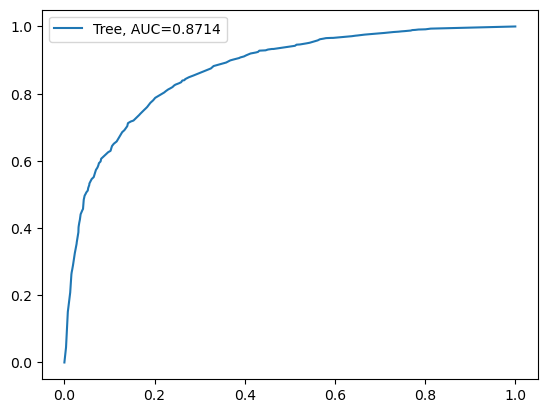

In [151]:
pred = Tree.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, pred[:,1])
plt.plot(fpr,tpr,label="Tree, AUC="+str(round(roc_auc_score(y_test, pred[:,1]), 4)))
plt.legend()

In [155]:
print(roc_auc_score(y_test, Tree.predict_proba(X_test)[:, 1]))

0.8713863518777635
